# 电商用户行为分析


## 一、数据准备、清洗与特征工程

In [188]:
#1.导入必要的库
import pandas as pd  # 数据处理
import numpy as np   # 数值计算
import matplotlib.pyplot as plt  # 绘图
import matplotlib.dates as mdates
import seaborn as sns  # 更美观的绘图
from datetime import datetime  # 日期处理

In [189]:
#2.导入数据
df = pd.read_csv('UserBehavior.csv',nrows=200000)  # 只读20万行

In [190]:
#3.给 DataFrame 设置列名
df.columns = ['用户ID', '商品ID', '商品类目ID','行为类型','时间戳']
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   用户ID    200000 non-null  int64 
 1   商品ID    200000 non-null  int64 
 2   商品类目ID  200000 non-null  int64 
 3   行为类型    200000 non-null  object
 4   时间戳     200000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 7.6+ MB


,用户ID,商品ID,商品类目ID,行为类型,时间戳
0,1,2333346,2520771,pv,1511561733
1,1,2576651,149192,pv,1511572885
2,1,3830808,4181361,pv,1511593493
3,1,4365585,2520377,pv,1511596146
4,1,4606018,2735466,pv,1511616481
5,1,230380,411153,pv,1511644942
6,1,3827899,2920476,pv,1511713473
7,1,3745169,2891509,pv,1511725471
8,1,1531036,2920476,pv,1511733732
9,1,2266567,4145813,pv,1511741471


In [191]:
#4.时间戳是整数，需要转换为日期时间格式
df['日期时间'] = pd.to_datetime(df['时间戳'], unit='s')  # unit='s'表示秒
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   用户ID    200000 non-null  int64         
 1   商品ID    200000 non-null  int64         
 2   商品类目ID  200000 non-null  int64         
 3   行为类型    200000 non-null  object        
 4   时间戳     200000 non-null  int64         
 5   日期时间    200000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 9.2+ MB


,用户ID,商品ID,商品类目ID,行为类型,时间戳,日期时间
0,1,2333346,2520771,pv,1511561733,2017-11-24 22:15:33
1,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25
2,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53
3,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06
4,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01
5,1,230380,411153,pv,1511644942,2017-11-25 21:22:22
6,1,3827899,2920476,pv,1511713473,2017-11-26 16:24:33
7,1,3745169,2891509,pv,1511725471,2017-11-26 19:44:31
8,1,1531036,2920476,pv,1511733732,2017-11-26 22:02:12
9,1,2266567,4145813,pv,1511741471,2017-11-27 00:11:11


In [192]:
#5.提取日期、小时、星期几等特征
df['日期'] = pd.to_datetime(df['日期时间'].dt.date)  # 只保留日期部分
df['小时'] = df['日期时间'].dt.hour  # 提取小时（0-23）
df['星期几'] = df['日期时间'].dt.dayofweek+1  # 周一=1, 周日=7
df['是否周末'] = df['星期几'].apply(lambda x: 1 if x >= 6 else 0)  # 周末标记
df.head(10)

,用户ID,商品ID,商品类目ID,行为类型,时间戳,日期时间,日期,小时,星期几,是否周末
0,1,2333346,2520771,pv,1511561733,2017-11-24 22:15:33,2017-11-24,22,5,0
1,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25,2017-11-25,1,6,1
2,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53,2017-11-25,7,6,1
3,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06,2017-11-25,7,6,1
4,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01,2017-11-25,13,6,1
5,1,230380,411153,pv,1511644942,2017-11-25 21:22:22,2017-11-25,21,6,1
6,1,3827899,2920476,pv,1511713473,2017-11-26 16:24:33,2017-11-26,16,7,1
7,1,3745169,2891509,pv,1511725471,2017-11-26 19:44:31,2017-11-26,19,7,1
8,1,1531036,2920476,pv,1511733732,2017-11-26 22:02:12,2017-11-26,22,7,1
9,1,2266567,4145813,pv,1511741471,2017-11-27 00:11:11,2017-11-27,0,1,0


In [193]:
 #6.创建购买标记（如果行为类型中有'buy'）
df['是否购买'] = df['行为类型'].apply(lambda x: 1 if x == 'buy' else 0)
df.head(10)

,用户ID,商品ID,商品类目ID,行为类型,时间戳,日期时间,日期,小时,星期几,是否周末,是否购买
0,1,2333346,2520771,pv,1511561733,2017-11-24 22:15:33,2017-11-24,22,5,0,0
1,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25,2017-11-25,1,6,1,0
2,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53,2017-11-25,7,6,1,0
3,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06,2017-11-25,7,6,1,0
4,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01,2017-11-25,13,6,1,0
5,1,230380,411153,pv,1511644942,2017-11-25 21:22:22,2017-11-25,21,6,1,0
6,1,3827899,2920476,pv,1511713473,2017-11-26 16:24:33,2017-11-26,16,7,1,0
7,1,3745169,2891509,pv,1511725471,2017-11-26 19:44:31,2017-11-26,19,7,1,0
8,1,1531036,2920476,pv,1511733732,2017-11-26 22:02:12,2017-11-26,22,7,1,0
9,1,2266567,4145813,pv,1511741471,2017-11-27 00:11:11,2017-11-27,0,1,0,0


In [194]:
#7.清洗异常数据
df.groupby('日期')['用户ID'].count()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   用户ID    200000 non-null  int64         
 1   商品ID    200000 non-null  int64         
 2   商品类目ID  200000 non-null  int64         
 3   行为类型    200000 non-null  object        
 4   时间戳     200000 non-null  int64         
 5   日期时间    200000 non-null  datetime64[ns]
 6   日期      200000 non-null  datetime64[ns]
 7   小时      200000 non-null  int32         
 8   星期几     200000 non-null  int32         
 9   是否周末    200000 non-null  int64         
 10  是否购买    200000 non-null  int64         
dtypes: datetime64[ns](2), int32(2), int64(6), object(1)
memory usage: 15.3+ MB


In [195]:
#从上面结果发现，数据集中包含了2017-11-24及之前的无用数据
df = df[(df['日期'] >= '2017-11-25') & (df['日期'] <= '2017-12-03')]
df.info()
df.groupby('日期')['用户ID'].count()

<class 'pandas.core.frame.DataFrame'>
Index: 197188 entries, 1 to 199999
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   用户ID    197188 non-null  int64         
 1   商品ID    197188 non-null  int64         
 2   商品类目ID  197188 non-null  int64         
 3   行为类型    197188 non-null  object        
 4   时间戳     197188 non-null  int64         
 5   日期时间    197188 non-null  datetime64[ns]
 6   日期      197188 non-null  datetime64[ns]
 7   小时      197188 non-null  int32         
 8   星期几     197188 non-null  int32         
 9   是否周末    197188 non-null  int64         
 10  是否购买    197188 non-null  int64         
dtypes: datetime64[ns](2), int32(2), int64(6), object(1)
memory usage: 16.5+ MB


日期
2017-11-25    20172
2017-11-26    20693
2017-11-27    19568
2017-11-28    20696
2017-11-29    20712
2017-11-30    21092
2017-12-01    22655
2017-12-02    27983
2017-12-03    23617
Name: 用户ID, dtype: int64

In [196]:
#8.数据去重（如果有完全重复的行）
df = df.drop_duplicates()
# 更新索引
df.reset_index(drop=True, inplace=True)
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197188 entries, 0 to 197187
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   用户ID    197188 non-null  int64         
 1   商品ID    197188 non-null  int64         
 2   商品类目ID  197188 non-null  int64         
 3   行为类型    197188 non-null  object        
 4   时间戳     197188 non-null  int64         
 5   日期时间    197188 non-null  datetime64[ns]
 6   日期      197188 non-null  datetime64[ns]
 7   小时      197188 non-null  int32         
 8   星期几     197188 non-null  int32         
 9   是否周末    197188 non-null  int64         
 10  是否购买    197188 non-null  int64         
dtypes: datetime64[ns](2), int32(2), int64(6), object(1)
memory usage: 15.0+ MB


,用户ID,商品ID,商品类目ID,行为类型,时间戳,日期时间,日期,小时,星期几,是否周末,是否购买
0,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25,2017-11-25,1,6,1,0
1,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53,2017-11-25,7,6,1,0
2,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06,2017-11-25,7,6,1,0
3,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01,2017-11-25,13,6,1,0
4,1,230380,411153,pv,1511644942,2017-11-25 21:22:22,2017-11-25,21,6,1,0
5,1,3827899,2920476,pv,1511713473,2017-11-26 16:24:33,2017-11-26,16,7,1,0
6,1,3745169,2891509,pv,1511725471,2017-11-26 19:44:31,2017-11-26,19,7,1,0
7,1,1531036,2920476,pv,1511733732,2017-11-26 22:02:12,2017-11-26,22,7,1,0
8,1,2266567,4145813,pv,1511741471,2017-11-27 00:11:11,2017-11-27,0,1,0,0
9,1,2951368,1080785,pv,1511750828,2017-11-27 02:47:08,2017-11-27,2,1,0,0


## 二、探索性数据分析与可视化

### （一）全局图像设置

In [197]:
# 设置画图的样式
plt.style.use('seaborn-v0_8')  # 使用seaborn的样式，让图更好看
sns.set_palette("husl")  # 设置颜色主题

# 设置中文显示（如果图表需要显示中文）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

#注意：这两段代码顺序不能变，否则'seaborn-v0_8'会覆盖rcParams设置

### （二）绘图

#### 1.行为类型分布

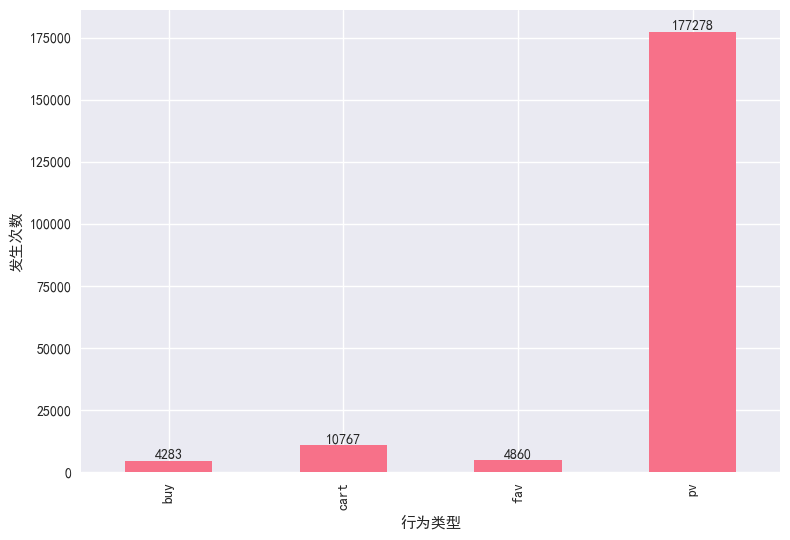

已保存为'行为类型分布.png'


In [198]:
ax1=df.groupby('行为类型')['用户ID'].count().plot(kind='bar',xlabel='行为类型',ylabel='发生次数')
ax1.bar_label(ax1.containers[0], fontsize=10)
plt.tight_layout()
plt.savefig('行为类型分布.png', dpi=300, bbox_inches='tight') 
plt.show()
print("已保存为'行为类型分布.png'")

#### 2.每日活跃用户趋势图

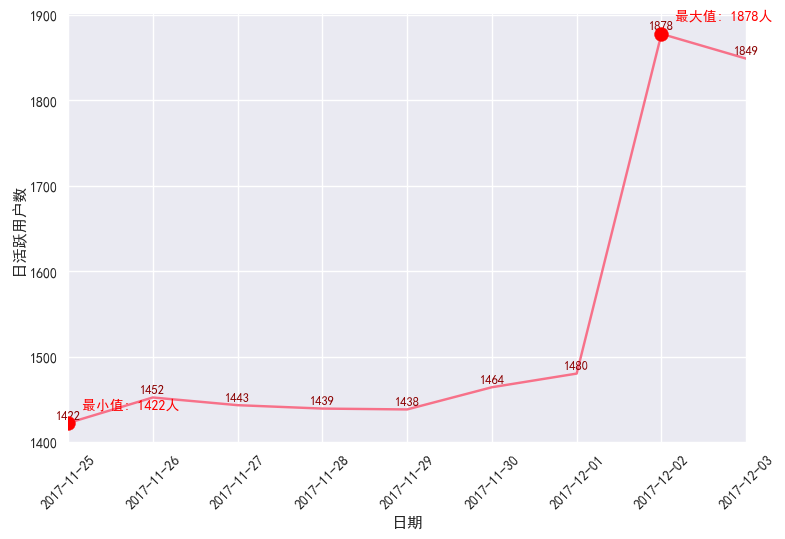

已保存为'每日活跃用户趋势图.png'


In [199]:
daily_users=df.groupby('日期')['用户ID'].nunique()
ax2=daily_users.plot(kind='line',xlabel='日期',ylabel='日活跃用户数')

# 2. 找到最高点和最低点
max_day = daily_users.idxmax()
max_users = daily_users.max()
min_day = daily_users.idxmin()
min_users = daily_users.min()

ax2.scatter([max_day, min_day], [max_users, min_users], color='red', s=100, zorder=5) 
ax2.annotate(f'最大值: {max_users}人',
             xy=(max_day, max_users), #要标注的点位置
             xytext=(10, 10), #标注文字的位置
             textcoords='offset points', #textcoords='offset points'是设置xytext的设置方式为相对位移（右10，上10）
             fontsize=10, 
             color='red')

ax2.annotate(f'最小值: {min_users}人',
             xy=(min_day, min_users), #要标注的点位置
             xytext=(10, 10), #标注文字的位置
             textcoords='offset points', #textcoords='offset points'是设置xytext的设置方式为相对位移（右10，上10）
             fontsize=10, 
             color='red')


ax2.xaxis.set_major_locator(mdates.DayLocator(interval=1))  # 每天一个刻度
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # 格式化为 YYYY-MM-DD
plt.xticks(rotation=45) # 旋转日期标签，避免重叠

# 3.标注数据点
for x, y in zip(daily_users.index, daily_users.values):
    ax2.text(x, y + 5, str(y), ha='center', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig('每日活跃用户趋势图.png', dpi=300, bbox_inches='tight') 
plt.show()
print("已保存为'每日活跃用户趋势图.png'")

#### 3.24小时用户活跃热力图

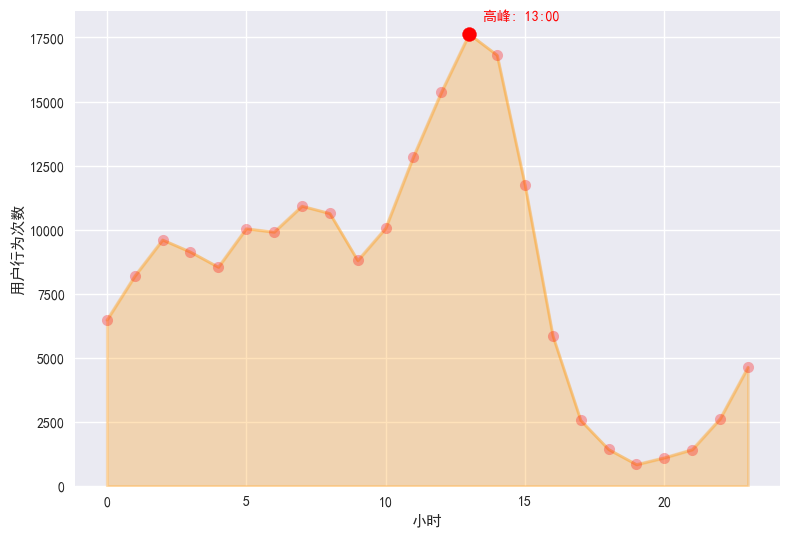

已保存为'24小时活跃度.png'


In [200]:
# 计算每小时的活跃度（总行为数）
hourly_activity = df.groupby('小时')['行为类型'].size()

# 创建面积图
ax3=hourly_activity.plot(kind='area',          
     alpha=0.3,            # 填充透明度（和你原代码一致）
     color='#FF9F1C',      # 填充色+轮廓线颜色
     linewidth=2,          # 轮廓线宽度（对应你原代码的折线宽度）
     xlabel='小时',        
     ylabel='用户行为次数')
# 关键：手动给面积图的轮廓线加marker
ax3.lines[0].set_marker('o')        # 标记点样式
ax3.lines[0].set_markersize(8)      # 大小
ax3.lines[0].set_markerfacecolor('red') # 填充色
ax3.lines[0].set_markeredgecolor('#FF9F1C') # 边框色
# 标记活跃高峰期
max_hour = hourly_activity.idxmax()
max_activity = hourly_activity.max()
ax3.scatter(max_hour, max_activity, color='red', s=100, zorder=5)
ax3.annotate(f'高峰: {max_hour}:00', xy=(max_hour, max_activity), xytext=(10, 10),
             textcoords='offset points', fontsize=10, color='red')

plt.tight_layout()
plt.savefig('24小时活跃度.png', dpi=300, bbox_inches='tight')
plt.show()
print("已保存为'24小时活跃度.png'")

#### 4.绘制热门商品类目Top 20

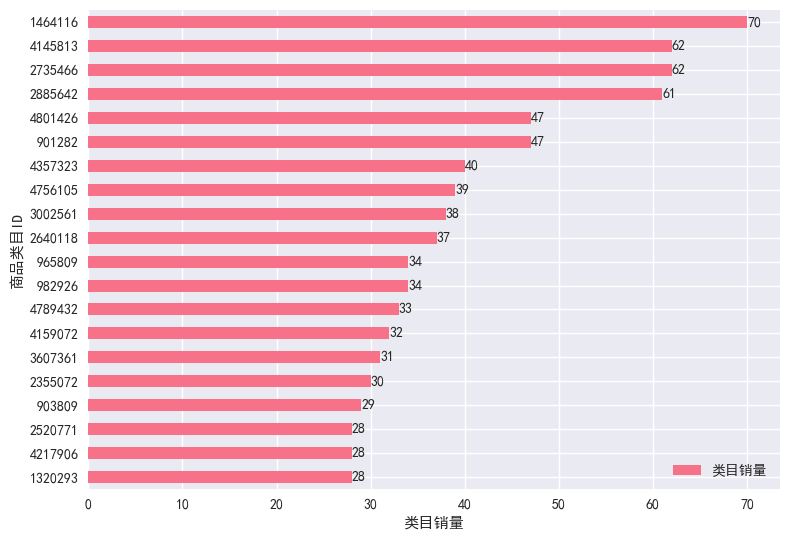

已保存为'热门商品类目Top 20.png'


In [201]:
goods_num=df[df['行为类型']=='buy'].groupby('商品类目ID')['行为类型'].count()
goods_num_sorted=goods_num.sort_values(ascending=False)
goods_df = goods_num_sorted.reset_index(name='类目销量')
goods_df['排名']=goods_df['类目销量'].rank(method='first',ascending=False)
goods_df=goods_df[goods_df['排名']<=20]
ax4=goods_df.plot(kind='barh',x='商品类目ID',y='类目销量',xlabel='类目销量', ylabel='商品类目ID')
ax4.bar_label(ax4.containers[0], fontsize=10)
ax4.invert_yaxis()
plt.tight_layout()
plt.savefig('热门商品类目Top 20', dpi=300, bbox_inches='tight')
plt.show()
print("已保存为'热门商品类目Top 20.png'")

## 三、漏斗分析与用户分群

### （一）漏斗分析

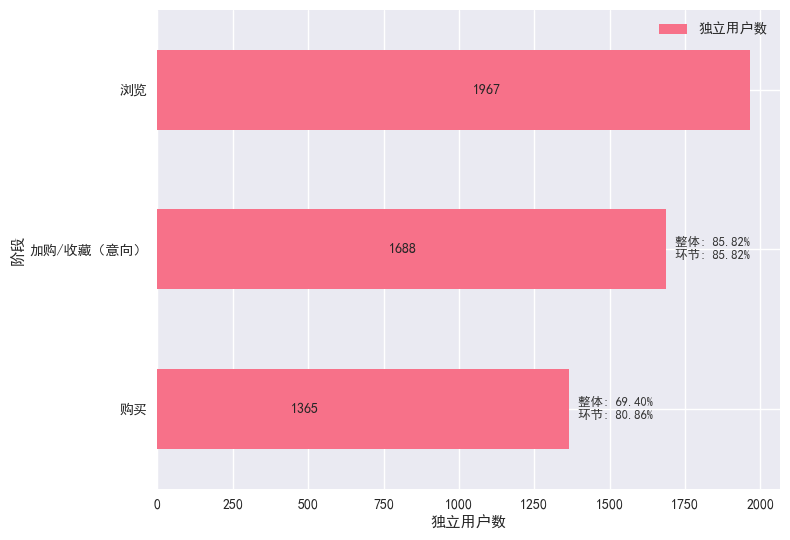

已保存为'漏斗分析.png'


In [202]:
# 1. 计算每个阶段的独立用户数（核心修改点）
pv_users = df[df['行为类型'] == 'pv']['用户ID'].nunique()# 浏览用户数

# 意向用户数（加购 OR 收藏）
# 先找出所有有过加购或收藏行为的用户，然后去重
cart_users = set(df[df['行为类型'] == 'cart']['用户ID'].unique())
fav_users = set(df[df['行为类型'] == 'fav']['用户ID'].unique())
interest_users = len(cart_users.union(fav_users))  # 取并集，去重

# 购买用户数
buy_users = df[df['行为类型'] == 'buy']['用户ID'].nunique()

# 2. 构建三步漏斗数据
funnel_data = [
    {'阶段': '浏览', '独立用户数': pv_users},
    {'阶段': '加购/收藏（意向）', '独立用户数': interest_users},  # 合并后的阶段
    {'阶段': '购买', '独立用户数': buy_users}
]
funnel_df = pd.DataFrame(funnel_data)
# 3. 计算各环节转化率
funnel_df['整体转化率']=funnel_df['独立用户数']/funnel_df['独立用户数'].iloc[0]*100
funnel_df['整体转化率'] = funnel_df['整体转化率'].apply(lambda x: f"{x:.2f}%")
funnel_df['环节转化率'] ='-'
for i in range(1, len(funnel_df)):
    rate = funnel_df.loc[i, '独立用户数'] / funnel_df.loc[i-1, '独立用户数'] * 100
    funnel_df.loc[i, '环节转化率'] = f"{rate:.2f}%"
# 4. 创建漏斗图
ax5=funnel_df.plot(kind='barh',x='阶段',y='独立用户数',xlabel='独立用户数')
ax5.bar_label(ax5.containers[0], fmt='%d', padding=-200, fontsize=10)
ax5.invert_yaxis()
for i, row in funnel_df.iterrows():#在条形右侧标注整体转化率和环节转化率
    # 整体转化率
    overall_rate = f"整体: {row['整体转化率']}"
    # 环节转化率
    step_rate = f"环节: {row['环节转化率']}"
    if i>0:
        # 在条形右侧添加文本
        ax5.text(
            x=row['独立用户数'] + 30,  # 位置在条形右侧一点
            y=i,
            s=f"{overall_rate}\n{step_rate}",
            va='center',  # 垂直居中
            fontsize=9,
            color='#333333'
        )
plt.tight_layout()
plt.savefig('漏斗分析', dpi=300, bbox_inches='tight')
plt.show()
print("已保存为'漏斗分析.png'")

### （二）用户分群


------------------------------------------------------------
5. RFM用户分群分析
------------------------------------------------------------
购买记录总数: 4,283 条
有购买行为的独立用户数: 1,365 人
分析截止日期: 2017-12-03 15:59:45
分析 1,365 个购买用户的RFM值...
RFM数据计算完成，共分析 1,365 个用户

RFM用户分群结果：
         平均最近购买天数  平均购买次数  平均消费指数  用户数
cluster                               
0            5.01    1.75    1.75  480
1            0.98    2.76    2.76  766
2            1.03    9.94    9.94  113
3            0.83   34.33   34.33    6

用户类型分布：
  一般用户: 478 人 (35.0%)
  潜力用户: 384 人 (28.1%)
  高价值用户: 330 人 (24.2%)
  流失风险用户: 173 人 (12.7%)

6. 创建用户分群可视化图表...


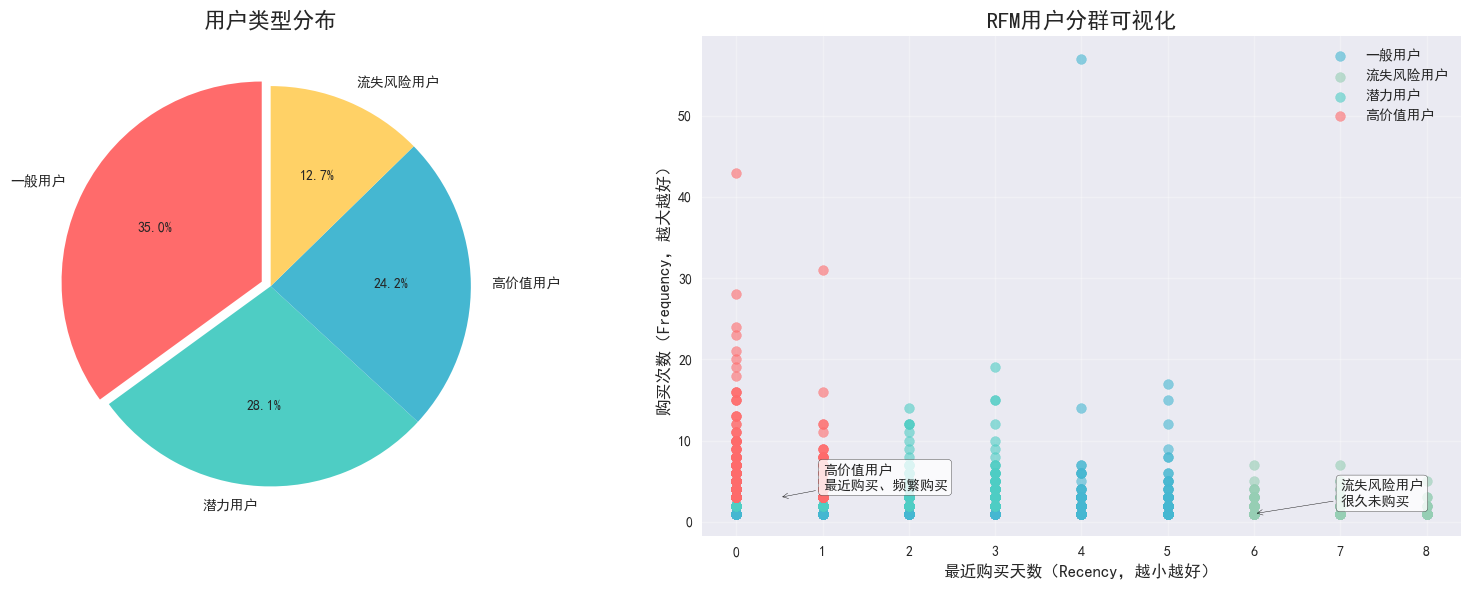

✓ 用户分群图已保存为 'RFM用户分群.png'
✓ RFM分析结果已保存为 'rfm_analysis_results.csv'

关键业务指标汇总

1. 用户行为统计：
   浏览(PV)行为: 177,278 次
   加购(Cart)行为: 10,767 次
   收藏(Fav)行为: 4,860 次
   购买(Buy)行为: 4,283 次

2. 转化漏斗分析：
   浏览用户数: 1,967 人
   意向用户数(加购或收藏): 1,688 人
   购买用户数: 1,365 人
   浏览→意向转化率: 85.82%
   意向→购买转化率: 80.86%
   整体购买转化率: 69.40%

3. RFM用户分群结果：
   一般用户: 478 人 (35.0%)
   潜力用户: 384 人 (28.1%)
   高价值用户: 330 人 (24.2%)
   流失风险用户: 173 人 (12.7%)

✓ 关键业务指标已保存为 '关键业务指标.csv'


In [203]:
# 5. RFM用户分群分析
print("\n" + "-" * 60)
print("5. RFM用户分群分析")
print("-" * 60)

# 筛选购买行为数据
purchase_df = df[df['行为类型'] == 'buy'].copy()
print(f"购买记录总数: {len(purchase_df):,} 条")
print(f"有购买行为的独立用户数: {purchase_df['用户ID'].nunique():,} 人")

# 确定分析截止日期（数据中的最后一天）
analysis_date = df['日期时间'].max()
print(f"分析截止日期: {analysis_date}")

# 为了确保分析质量，我们分析所有购买用户
sample_users = purchase_df['用户ID'].unique()

print(f"分析 {len(sample_users):,} 个购买用户的RFM值...")

rfm_data = []
for user_id in sample_users:
    user_purchases = purchase_df[purchase_df['用户ID'] == user_id]
    
    # R值：最近一次购买距离分析日期的天数
    last_purchase = user_purchases['日期时间'].max()
    recency = (analysis_date - last_purchase).days
    
    # F值：购买频率（购买次数）
    frequency = len(user_purchases)
    
    # M值：由于数据集中不包含消费金额，本次RFM分析中的M值（消费能力）由F值（消费频率）替代，结论更侧重于用户的购买活跃度而非客单价。
    monetary = frequency
    
    rfm_data.append({
        '用户ID': user_id,
        'Recency': recency,
        'Frequency': frequency,
        'Monetary': monetary
    })

rfm_df = pd.DataFrame(rfm_data)
print(f"RFM数据计算完成，共分析 {len(rfm_df):,} 个用户")

# 标准化数据
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

# K-Means聚类（分4个群）
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['cluster'] = kmeans.fit_predict(rfm_scaled)
# 分析每个群的特征
cluster_summary = rfm_df.groupby('cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    '用户ID': 'count'
}).round(2)

cluster_summary.columns = ['平均最近购买天数', '平均购买次数', '平均消费指数', '用户数']
print("\nRFM用户分群结果：")
print(cluster_summary)

# 给每个群命名
def assign_segment(row):
    """根据RFM值给用户分类"""
    # 这里的分群逻辑可以根据实际数据分布调整
    if row['Recency'] <= 1 and row['Frequency'] >= 3:
        return '高价值用户'
    elif row['Recency'] <= 3 and row['Frequency'] >= 2:
        return '潜力用户'
    elif row['Recency'] > 5:
        return '流失风险用户'
    else:
        return '一般用户'

rfm_df['用户类型'] = rfm_df.apply(assign_segment, axis=1)

# 查看各类型用户分布
segment_dist = rfm_df['用户类型'].value_counts()
print("\n用户类型分布：")
for segment, count in segment_dist.items():
    percentage = count / len(rfm_df) * 100
    print(f"  {segment}: {count:,} 人 ({percentage:.1f}%)")

# 可视化用户分群结果
print("\n6. 创建用户分群可视化图表...")

# 创建图形和子图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 子图1：用户类型分布饼图
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFD166']
axes[0].pie(segment_dist.values, 
           labels=segment_dist.index, 
           autopct='%1.1f%%',
           startangle=90,
           colors=colors_pie,
           explode=[0.05, 0, 0, 0])  # 突出显示第一块
axes[0].set_title('用户类型分布', fontsize=16, fontweight='bold')

# 子图2：RFM散点图
segment_colors = {
    '高价值用户': '#FF6B6B',    # 红色
    '潜力用户': '#4ECDC4',      # 青色
    '一般用户': '#45B7D1',      # 蓝色
    '流失风险用户': '#96CEB4'   # 绿色
}

# 绘制散点图：最近购买天数 vs 购买次数
for segment in rfm_df['用户类型'].unique():
    segment_data = rfm_df[rfm_df['用户类型'] == segment]
    axes[1].scatter(segment_data['Recency'], 
                    segment_data['Frequency'], 
                    label=segment, 
                    alpha=0.6, 
                    s=50, 
                    color=segment_colors[segment])

axes[1].set_xlabel('最近购买天数（Recency，越小越好）', fontsize=12)
axes[1].set_ylabel('购买次数（Frequency，越大越好）', fontsize=12)
axes[1].set_title('RFM用户分群可视化', fontsize=16, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 添加说明文字
axes[1].annotate('高价值用户\n最近购买、频繁购买', 
                xy=(0.5, 3), 
                xytext=(1, 4),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

axes[1].annotate('流失风险用户\n很久未购买', 
                xy=(6, 1), 
                xytext=(7, 2),
                arrowprops=dict(facecolor='black', arrowstyle='->'),
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('RFM用户分群.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 用户分群图已保存为 'RFM用户分群.png'")

# 保存RFM分析结果
rfm_df.to_csv('rfm_analysis_results.csv', index=False, encoding='utf-8-sig')
print("✓ RFM分析结果已保存为 'rfm_analysis_results.csv'")

# 计算关键业务指标
print("\n" + "=" * 60)
print("关键业务指标汇总")
print("=" * 60)

# 计算各行为类型的用户数
behavior_counts = df['行为类型'].value_counts()
pv_count = behavior_counts.get('pv', 0)
cart_count = behavior_counts.get('cart', 0)
fav_count = behavior_counts.get('fav', 0)
buy_count = behavior_counts.get('buy', 0)

# 计算关键转化率指标
pv_to_interest_rate = interest_users / pv_users * 100
interest_to_buy_rate = buy_users / interest_users * 100
overall_conversion_rate = buy_users / pv_users * 100

print(f"\n1. 用户行为统计：")
print(f"   浏览(PV)行为: {pv_count:,} 次")
print(f"   加购(Cart)行为: {cart_count:,} 次")
print(f"   收藏(Fav)行为: {fav_count:,} 次")
print(f"   购买(Buy)行为: {buy_count:,} 次")

print(f"\n2. 转化漏斗分析：")
print(f"   浏览用户数: {pv_users:,} 人")
print(f"   意向用户数(加购或收藏): {interest_users:,} 人")
print(f"   购买用户数: {buy_users:,} 人")
print(f"   浏览→意向转化率: {pv_to_interest_rate:.2f}%")
print(f"   意向→购买转化率: {interest_to_buy_rate:.2f}%")

print(f"   整体购买转化率: {overall_conversion_rate:.2f}%")

print(f"\n3. RFM用户分群结果：")
for segment, count in segment_dist.items():
    percentage = count / len(rfm_df) * 100
    print(f"   {segment}: {count:,} 人 ({percentage:.1f}%)")

# 保存关键指标
key_metrics = {
    '浏览用户数': pv_users,
    '意向用户数': interest_users,
    '购买用户数': buy_users,
    '浏览意向转化率': pv_to_interest_rate,
    '意向购买转化率': interest_to_buy_rate,
    '整体购买转化率': overall_conversion_rate,
    '高价值用户数': segment_dist.get('高价值用户', 0),
    '潜力用户数': segment_dist.get('潜力用户', 0),
    '流失风险用户数': segment_dist.get('流失风险用户', 0),
    '一般用户数': segment_dist.get('一般用户', 0)
}

metrics_df = pd.DataFrame(list(key_metrics.items()), columns=['指标', '值'])
metrics_df.to_csv('关键业务指标.csv', index=False, encoding='utf-8-sig')
print("\n✓ 关键业务指标已保存为 '关键业务指标.csv'")

## 四、总结与报告

In [204]:
# 第五部分：总结与报告
print("=" * 70)
print("电商用户行为分析总结报告")
print("=" * 70)

# 1. 项目概述
print("\n📋 一、项目概述")
print("  本项目基于淘宝用户行为数据集（2017年11月25日至12月3日），通过深入分析")
print("  用户从浏览、加购/收藏到购买的完整转化路径，结合RFM用户分群模型，旨在")
print("  识别关键转化节点，洞察用户价值分布，为精细化运营提供数据支持。")

# 2. 核心发现
print("\n🔍 二、核心发现")

print(f"\n  1. 用户转化漏斗分析（基于 {len(df):,} 条行为记录）")
print(f"    • 浏览(PV)用户数: {pv_users:,} 人")
print(f"    • 意向用户数(加购或收藏): {interest_users:,} 人")
print(f"    • 购买用户数: {buy_users:,} 人")
print(f"    • 关键转化率:")
print(f"      → 浏览→意向: {pv_to_interest_rate:.2f}% ({interest_users}/{pv_users})")
print(f"      → 意向→购买: {interest_to_buy_rate:.2f}% ({buy_users}/{interest_users})")
print(f"      → 整体购买: {overall_conversion_rate:.2f}% ({buy_users}/{pv_users})")

print(f"\n  2. 用户价值分群（基于RFM模型）")
print(f"    • 共分析 {len(rfm_df):,} 名购买用户")
for segment, count in segment_dist.items():
    percentage = count / len(rfm_df) * 100
    if segment == '高价值用户':
        print(f"    • {segment}: {count:,} 人 ({percentage:.1f}%) - 核心贡献用户")
    elif segment == '潜力用户':
        print(f"    • {segment}: {count:,} 人 ({percentage:.1f}%) - 重点培养用户")
    elif segment == '流失风险用户':
        print(f"    • {segment}: {count:,} 人 ({percentage:.1f}%) - 需召回用户")
    else:
        print(f"    • {segment}: {count:,} 人 ({percentage:.1f}%) - 常规运营用户")

# 3. 业务洞察
print("\n💡 三、关键业务洞察")

print(f"\n  1. 转化漏斗机会点")
print(f"    • 浏览→意向转化率 {pv_to_interest_rate:.2f}%，")
print(f"      意味着每100个浏览用户中有{pv_to_interest_rate:.0f}个产生兴趣")
print(f"    • 意向→购买转化率 {interest_to_buy_rate:.2f}%，")
print(f"      有{interest_users - buy_users:,}名意向用户尚未转化，是重要增长机会")

print(f"\n  2. 用户价值洞察")
high_value_pct = segment_dist.get('高价值用户', 0) / len(rfm_df) * 100
risk_pct = segment_dist.get('流失风险用户', 0) / len(rfm_df) * 100
print(f"    • 高价值用户占比 {high_value_pct:.1f}%，贡献主要GMV，需重点维护")
print(f"    • 流失风险用户占比 {risk_pct:.1f}%，需立即采取召回措施")

# 4. 具体建议
print("\n🎯 四、数据驱动的运营建议")

print(f"\n  1. 提升转化漏斗效率")
print(f"    • 针对{pv_users - interest_users:,}名浏览未意向用户：")
print(f"      → 优化商品详情页，突出核心卖点和用户评价")
print(f"      → 实施智能推荐，根据浏览历史推送相关商品")
print(f"    • 针对{interest_users - buy_users:,}名意向未购买用户：")
print(f"      → 加购后24小时未购买：推送限时优惠券（预计提升转化率5-10%）")
print(f"      → 收藏后72小时未购买：发送商品降价或库存提醒")

print(f"\n  2. 精细化用户运营策略")
print(f"\n  ● 超级用户/狂热粉丝 ({segment_dist.get('超级用户/狂热粉丝', 0):,}人):")
print(f"      → 策略目标：超高端维护，推动品牌忠诚与口碑传播")
print(f"      → 邀请参与新品内测、产品设计调研，赋予‘产品共创官’身份")
print(f"      → 提供全年免邮、专属客服经理、生日重磅礼遇")
print(f"      → 邀请其创作优质买家秀/评测内容，并给予高额奖励")
print(f"    • 高价值用户({segment_dist.get('高价值用户', 0):,}人)：")
print(f"      → 建立VIP专属服务体系，提供优先客服")
print(f"      → 每月1日推送会员专属权益和优惠")
print(f"      → 邀请参与新品试用和体验活动")
print(f"    • 潜力用户({segment_dist.get('潜力用户', 0):,}人)：")
print(f"      → 设置成长体系，消费满额升级为VIP")
print(f"      → 推送'猜你喜欢'个性化推荐，提高复购")
print(f"      → 开展'老带新'活动，拓展社交裂变")
print(f"    • 流失风险用户({segment_dist.get('流失风险用户', 0):,}人)：")
print(f"      → 30天未登录：发送回归礼包（无门槛优惠券）")
print(f"      → 60天未购买：推送爆款商品+专属折扣")
print(f"      → 分析流失原因，针对性优化商品和服务")


print(f"\n  3. 产品功能优化建议")
print(f"    • 根据24小时活跃度分析，用户晚间（20-22点）最活跃。因此，建议将‘加购未购买用户’的定向优惠券推送时间设置在晚上8点，此时触达和转化效果可能最佳。")
print(f"    • 优化收藏夹功能，增加'降价提醒'和'库存预警'")
print(f"    • 简化购买流程，减少页面跳转和操作步骤")

# 5. 预期效果量化
print("\n📈 五、预期效果量化（基于当前数据推算）")

# 计算潜在提升空间
potential_interest_users = int(pv_users * (pv_to_interest_rate + 2) / 100) - interest_users
potential_buyers_from_interest = int(interest_users * (interest_to_buy_rate + 3) / 100) - buy_users
total_potential_growth = potential_interest_users + potential_buyers_from_interest

print(f"  1. 转化率提升预期（假设优化后）：")
print(f"    • 浏览→意向转化率提升2个百分点 → 新增{potential_interest_users:,}名意向用户")
print(f"    • 意向→购买转化率提升3个百分点 → 新增{potential_buyers_from_interest:,}名购买用户")
print(f"    • 总购买用户预计增长约{total_potential_growth:,}人")

print(f"\n  2. 用户价值提升预期：")
high_value_growth = int(segment_dist.get('潜力用户', 0) * 0.15)  # 15%潜力用户转化为高价值用户
risk_reduction = int(segment_dist.get('流失风险用户', 0) * 0.20)  # 召回20%流失风险用户
print(f"    • 15%潜力用户转化为高价值用户 → 新增{high_value_growth:,}名高价值用户")
print(f"    • 20%流失风险用户被成功召回 → 减少{risk_reduction:,}名流失用户")

# 6. 项目产出物
print("\n📁 六、项目产出物")
print("  ✓ 完整的数据分析代码（Jupyter Notebook）")
print("  ✓ 用户转化漏斗图：'漏斗分析.png'")
print("  ✓ RFM用户分群图：'RFM用户分群.png'")
print("  ✓ RFM分析结果：'rfm_analysis_results.csv'")
print("  ✓ 关键业务指标：'关键业务指标.csv'")
print("  ✓ 清洗后的数据集：可用于进一步分析")
print("  ✓ 数据驱动的运营策略建议报告")

# 7. 后续分析方向
print("\n🚀 七、后续分析方向建议")
print("  1. 用户行为路径分析：分析用户从浏览到购买的典型路径")
print("  2. 商品关联分析：发现经常一起购买的商品组合")
print("  3. 时间序列分析：识别用户活跃的高峰时段和日期")
print("  4. 用户生命周期价值预测：基于历史数据预测用户未来价值")
print("  5. A/B测试设计：验证不同运营策略的实际效果")

print("\n" + "=" * 70)
print("分析报告生成完成！")
print("=" * 70)

电商用户行为分析总结报告

📋 一、项目概述
  本项目基于淘宝用户行为数据集（2017年11月25日至12月3日），通过深入分析
  用户从浏览、加购/收藏到购买的完整转化路径，结合RFM用户分群模型，旨在
  识别关键转化节点，洞察用户价值分布，为精细化运营提供数据支持。

🔍 二、核心发现

  1. 用户转化漏斗分析（基于 197,188 条行为记录）
    • 浏览(PV)用户数: 1,967 人
    • 意向用户数(加购或收藏): 1,688 人
    • 购买用户数: 1,365 人
    • 关键转化率:
      → 浏览→意向: 85.82% (1688/1967)
      → 意向→购买: 80.86% (1365/1688)
      → 整体购买: 69.40% (1365/1967)

  2. 用户价值分群（基于RFM模型）
    • 共分析 1,365 名购买用户
    • 一般用户: 478 人 (35.0%) - 常规运营用户
    • 潜力用户: 384 人 (28.1%) - 重点培养用户
    • 高价值用户: 330 人 (24.2%) - 核心贡献用户
    • 流失风险用户: 173 人 (12.7%) - 需召回用户

💡 三、关键业务洞察

  1. 转化漏斗机会点
    • 浏览→意向转化率 85.82%，
      意味着每100个浏览用户中有86个产生兴趣
    • 意向→购买转化率 80.86%，
      有323名意向用户尚未转化，是重要增长机会

  2. 用户价值洞察
    • 高价值用户占比 24.2%，贡献主要GMV，需重点维护
    • 流失风险用户占比 12.7%，需立即采取召回措施

🎯 四、数据驱动的运营建议

  1. 提升转化漏斗效率
    • 针对279名浏览未意向用户：
      → 优化商品详情页，突出核心卖点和用户评价
      → 实施智能推荐，根据浏览历史推送相关商品
    • 针对323名意向未购买用户：
      → 加购后24小时未购买：推送限时优惠券（预计提升转化率5-10%）
      → 收藏后72小时未购买：发送商品降价或库存提醒

  2. 精细化用户运营策略

  ● 超级用户/狂热粉丝 (0人):
 